# **Final Assignment**

## *Malin Jacobsson*


In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # for 3D scatterplots

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import load_wine
from sklearn.svm import SVC


In [24]:
xls = pd.ExcelFile("final_data.xlsx")

cars = pd.read_excel(xls, sheet_name="Used Car Sales")
projects = pd.read_excel(xls, sheet_name="Software Project Success")
coffee = pd.read_excel(xls, sheet_name="Coffee Bean Quality")

# Question 1: Price and Speed of Sale Prediction

## **A. Linear Regression: Price Prediction**

In [25]:
print(cars.columns)
print(cars.dtypes)
print(cars.head())


Index(['Car No.', 'Engine Size (L)', 'Mileage (km)', 'Price (€)',
       'Sold in 7 Days? (Y/N)'],
      dtype='object')
Car No.                    int64
Engine Size (L)          float64
Mileage (km)               int64
Price (€)                float64
Sold in 7 Days? (Y/N)     object
dtype: object
   Car No.  Engine Size (L)  Mileage (km)  Price (€) Sold in 7 Days? (Y/N)
0        1              2.0            50       18.0                     Y
1        2              1.4           120        8.5                     N
2        3              3.5            30       35.0                     Y
3        4              1.8            90       12.5                     Y
4        5              2.5            65       16.0                     N


In [26]:
# convert Y/N to 1/0 so it's easier to work with
cars["Sold in 7 Days? (Y/N)"] = cars["Sold in 7 Days? (Y/N)"].map({"Y": 1, "N": 0})

# linear regression 
X_lin = cars[["Engine Size (L)", "Mileage (km)"]]   # just using these two
y_lin = cars["Price (€)"]                           # predicting price

# logistic regression (same features, diff target)
X_log = X_lin                                       # reused it, same thing
y_log = cars["Sold in 7 Days? (Y/N)"]

# quick sanity check
print(X_lin.head())
print(y_lin.head())
print(y_log.value_counts())



   Engine Size (L)  Mileage (km)
0              2.0            50
1              1.4           120
2              3.5            30
3              1.8            90
4              2.5            65
0    18.0
1     8.5
2    35.0
3    12.5
4    16.0
Name: Price (€), dtype: float64
Sold in 7 Days? (Y/N)
1    6
0    4
Name: count, dtype: int64


### Q1.A.1 Model Fitting

In [27]:
# train/test split (80/20). kept the random_state so results don't jump around
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

# basic linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_lin, y_train_lin)

# just checking what the model looks like
print("intercept:", lin_reg.intercept_)
print("coef:", lin_reg.coef_)
print("train R2:", lin_reg.score(X_train_lin, y_train_lin))
print("test R2:", lin_reg.score(X_test_lin, y_test_lin))


intercept: 1.5015593792099722
coef: [ 9.56139638 -0.0774839 ]
train R2: 0.9383320067871347
test R2: -25.44374166773663


### Q1.A.2 Visualization

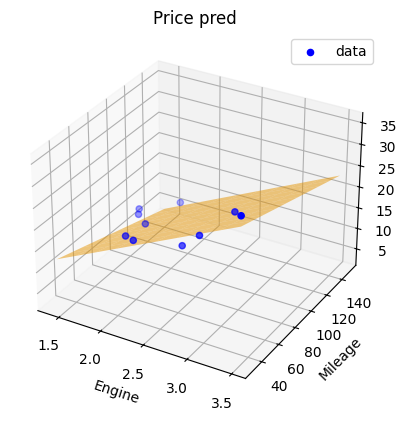

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# plot the data
ax.scatter(X_lin["Engine Size (L)"], X_lin["Mileage (km)"], y_lin, c='blue', label='data')

# surface from model
x_surf, y_surf = np.meshgrid(
    np.linspace(X_lin["Engine Size (L)"].min(), X_lin["Engine Size (L)"].max(), 10),
    np.linspace(X_lin["Mileage (km)"].min(), X_lin["Mileage (km)"].max(), 10)
)
z_surf = lin_reg.intercept_ + lin_reg.coef_[0]*x_surf + lin_reg.coef_[1]*y_surf  # kept random_state lol
ax.plot_surface(x_surf, y_surf, z_surf, color='orange', alpha=0.5)

ax.set_xlabel("Engine")
ax.set_ylabel("Mileage")
ax.set_zlabel("Price")
plt.title("Price pred")
plt.legend()
plt.show()



### Q1.A.3 Analysis
*Analysis provided in Word document.*

## **B. Logistic Regression: Quick Sale Classification** 

### Q1.B.1 Model Fitting

In [29]:
# split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42)  # kept random_state

# fit model
log_reg = LogisticRegression()
log_reg.fit(X_train_log, y_train_log)

print("Intercept:", log_reg.intercept_[0])
print("Coefs:", log_reg.coef_[0])  # Engine Size, Mileage
print("Acc:", accuracy_score(y_test_log, log_reg.predict(X_test_log)))


Intercept: 6.181287013115383
Coefs: [-0.56543976 -0.06232954]
Acc: 0.5


### Q1.B.2 Visualization

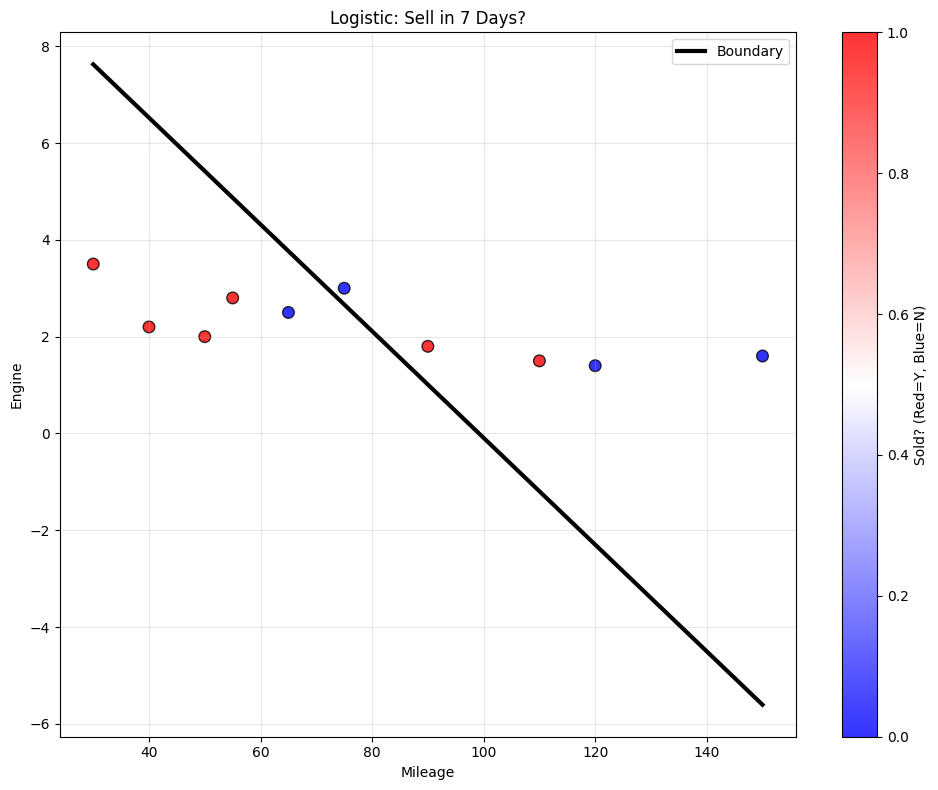

In [30]:
# Big mistake 1. I had already mapped the Sold in 7 Days? column to binary values (1 for Y, 0 for N), 
# but when I made the scatter plot I still used the original strings “Y” and “N.” 
# Once I realized what I’d done, fixing it was pretty straightforward.

plt.figure(figsize=(10, 8))

# scatter plot
scatter = plt.scatter(cars["Mileage (km)"], 
                      cars["Engine Size (L)"],
                      c=y_log, 
                      cmap="bwr", 
                      alpha=0.8, 
                      edgecolors='k', 
                      s=70)
plt.colorbar(scatter, label="Sold? (Red=Y, Blue=N)")

# decision boundary
coef = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

x_vals = np.linspace(cars["Mileage (km)"].min(), cars["Mileage (km)"].max(), 200)
y_vals = -(intercept + coef[1] * x_vals) / coef[0]

plt.plot(x_vals, y_vals, color='black', linewidth=3, label="Boundary")

plt.xlabel("Mileage")
plt.ylabel("Engine")
plt.title("Logistic: Sell in 7 Days?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Q1.B.3 Analysis
*Analysis provided in Word document.*

---

# Question 2: The Logic of Failure

## **A. The "Failure Pathway" Decision Tree**

In [31]:
print(projects.columns)
print(projects.dtypes)
print(projects.head())

Index(['Project No.', 'Team Size', 'QA Coverage (%)', 'Schedule (Days)',
       'Tech Stack (Old/New)', 'Success? (Y/N)'],
      dtype='object')
Project No.              int64
Team Size                int64
QA Coverage (%)          int64
Schedule (Days)          int64
Tech Stack (Old/New)    object
Success? (Y/N)          object
dtype: object
   Project No.  Team Size  QA Coverage (%)  Schedule (Days)  \
0            1          5               95              100   
1            2         12               70              180   
2            3          7               85               90   
3            4         15               60              200   
4            5          6               90              110   

  Tech Stack (Old/New) Success? (Y/N)  
0                  New              Y  
1                  Old              N  
2                  New              Y  
3                  Old              N  
4                  New              Y  


### Q2.A.1 Model Fitting

In [32]:
# These comments are for my sanitys sake

# target (1=Y, 0=N)
y = (projects["Success? (Y/N)"] == "Y").astype(int)

# features
X_raw = projects[["Team Size", "QA Coverage (%)", "Schedule (Days)", "Tech Stack (Old/New)"]]

# one-hot encode tech stack
enc = OneHotEncoder(sparse_output=False)
X_enc = enc.fit_transform(X_raw[["Tech Stack (Old/New)"]])

# combine numeric + encoded
X_num = X_raw[["Team Size", "QA Coverage (%)", "Schedule (Days)"]].values
X = pd.DataFrame(
    data=np.hstack([X_num, X_enc]),
    columns=["Team Size", "QA Coverage (%)", "Schedule (Days)"] 
            + list(enc.get_feature_names_out(["Tech Stack (Old/New)"]))
)

# fit decision tree
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42  # kept random_state lol
)
dt.fit(X, y)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Q2.A.2 Visualization

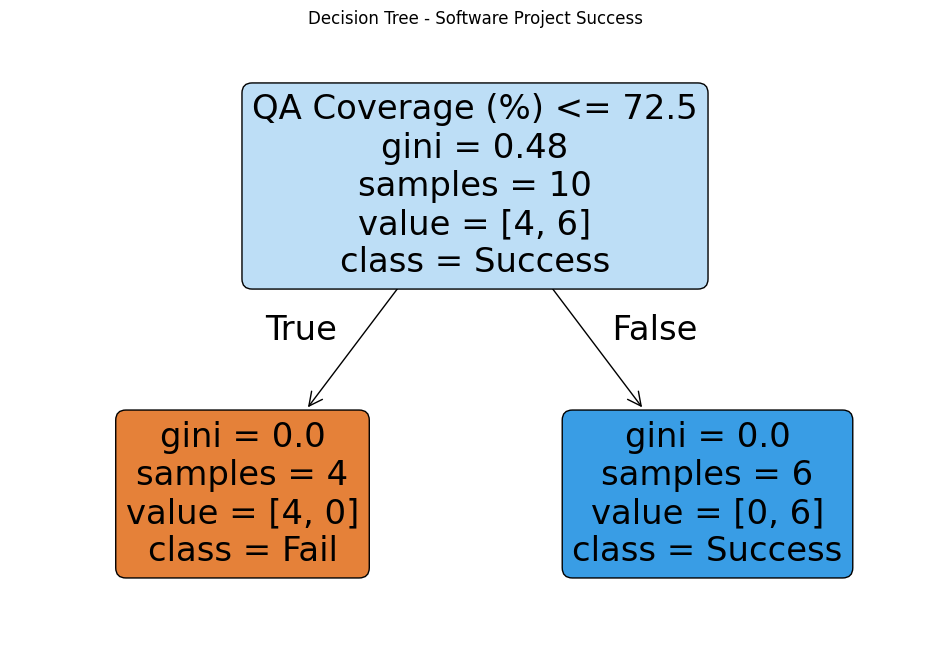

In [34]:
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Fail", "Success"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree - Software Project Success")
plt.show()


### Q2.A.2b Path Extraction

In [64]:
tree = dt.tree_

# Andel misslyckade projekt i varje nod (comments in swedish for MY understanding)
failure_ratios = tree.value[:, 0, 0] / tree.value.sum(axis=2)[:, 0]

# Hitta noden med högst failure ratio
worst_node = np.argmax(failure_ratios)

# Hämta samples och ratio
samples = tree.n_node_samples[worst_node]
ratio = failure_ratios[worst_node]

print(f"Failure node: {worst_node}, samples: {samples}, failure ratio: {ratio:.2f}")

Failure node: 1, samples: 4, failure ratio: 1.00


### Q2.A.3 Analysis
*Analysis provided in Word document.*

## **B. Random Forest**

### Q2.B.1 Model Fitting

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,   
    max_depth=None,     
    random_state=42
)
rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Q2.B.2 Feature Importance

In [36]:
importances = rf.feature_importances_
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feature_imp)

Team Size                   0.292929
QA Coverage (%)             0.287879
Schedule (Days)             0.239899
Tech Stack (Old/New)_New    0.098485
Tech Stack (Old/New)_Old    0.080808
dtype: float64


### Q2.B.3 Visualization

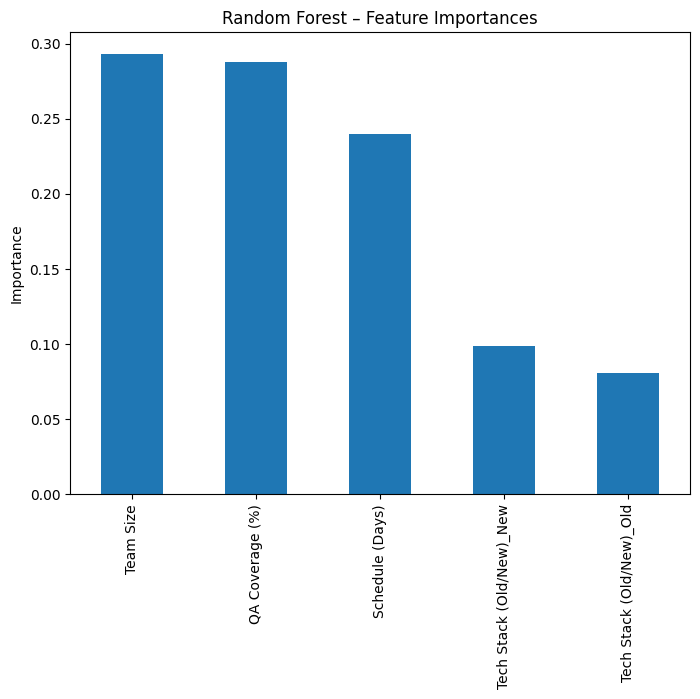

In [37]:
plt.figure(figsize=(8,6))
feature_imp.plot(kind="bar")
plt.title("Random Forest – Feature Importances")
plt.ylabel("Importance")
plt.show()

### Q2.B.4 Hypothesis & Defence
*Analysis provided in Word document.*

---

# Question 3: The K-Means Balancing Act

This question is fully covered in the Word document. All calculations, iterations, and the final visualization are shown there.
(Notebook continues with Question 4.)

---

# Question 4: Uncorking the Data (Wine Dataset)

In [3]:
wine = load_wine()
X = wine.data
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## Part A: Unsupervised Exploration
### Q4.A.1 Elbow Method

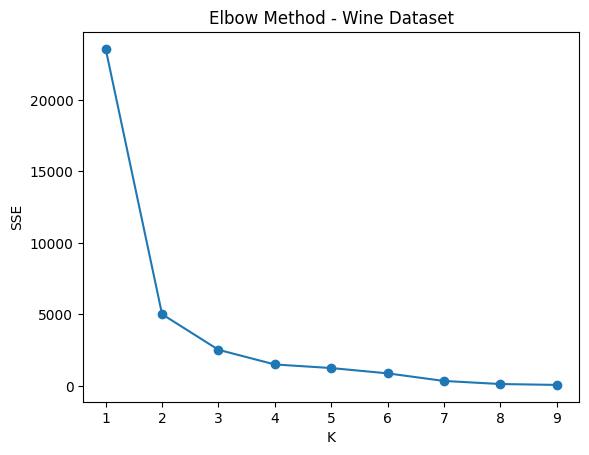

In [ ]:
# test different K values (1-10) to find the elbow point
inertias = []
ks = range(1, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)  # keep same seed for reproducibility
    km.fit(X)
    inertias.append(km.inertia_)  # store SSE for plotting

# simple plot to inspect elbow
plt.plot(list(ks), inertias, "o-")
plt.title("Elbow Method - Wine Dataset")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.show()


### Q4.A.2 PCA

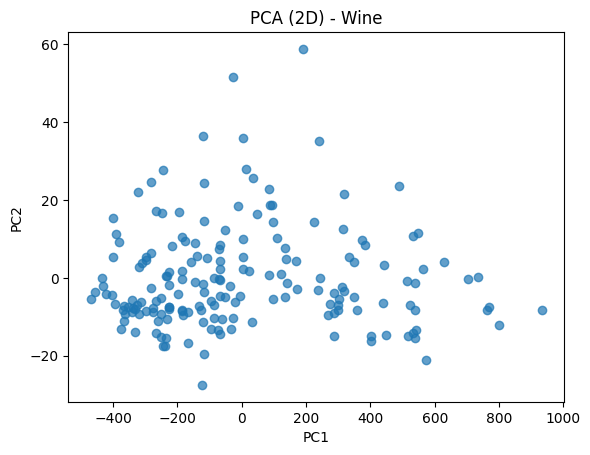

In [ ]:
# reducing it to 2 comps
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# quick scatter plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) - Wine")
plt.show()


### Q4.A.3 Silhouette

In [ ]:
# trying silhouette scores for K=1..10 (can't do K=1 obviously)
sil_scores = []

for k in ks:
    if k > 1:
        km = KMeans(n_clusters=k, random_state=42)
        labs = km.fit_predict(X_pca)
        sil_scores.append(silhouette_score(X_pca, labs))
    else:
        sil_scores.append(None)   # placeholder so the plot lines up

# quick plot, just to see where it peaks
plt.plot(list(ks), sil_scores, "o-")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Silhouette (PCA data)")
plt.show()

### Q4.A.4 Final Visualization

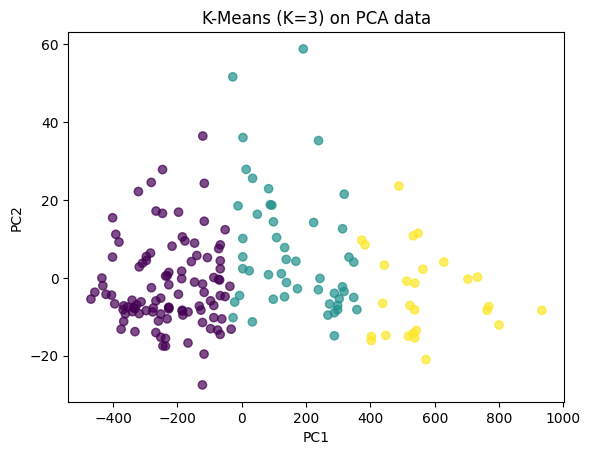

In [18]:
# went with K=3 based on the elbow andsilhouette thing
best_k = 3

km_final = KMeans(n_clusters=best_k, random_state=42)
final_labels = km_final.fit_predict(X_pca)

# simple scatter to see how it looks in 2D
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels,
            cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means (K={best_k}) on PCA data")
plt.show()


## Part B: Supervised Classification
### Q4.B.1 Data Setup

In [8]:
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q4.B.2 Model Selection

In [11]:
# Model 1: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Model 2: SVM (Wildcard)
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Q4.B.3 Visual Comparison


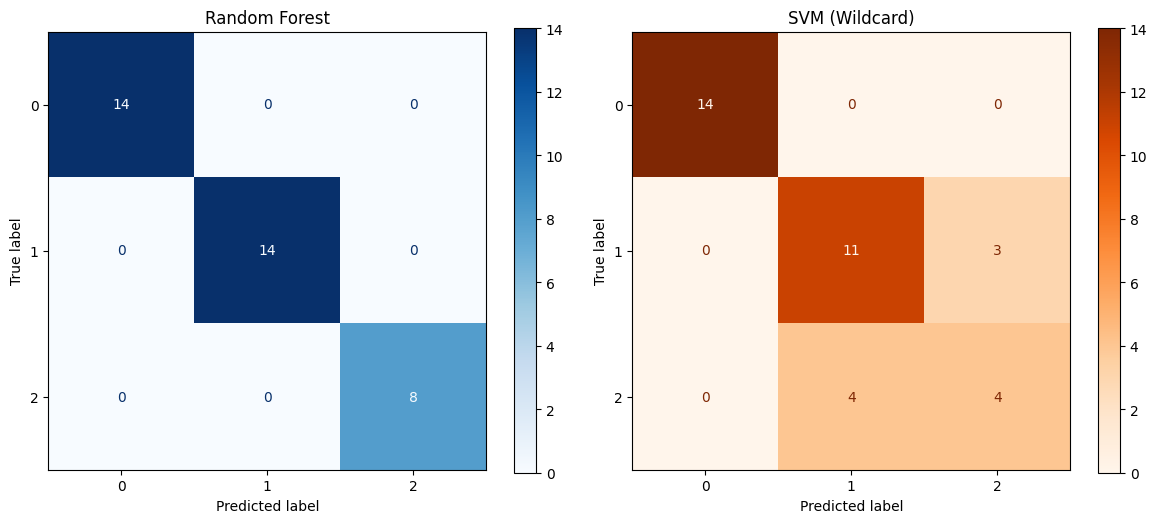

In [19]:
# comparing the two models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RF confusion matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest")

# SVM confusion matrix
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, ax=axes[1], cmap="Oranges")
axes[1].set_title("SVM (Wildcard)")

plt.tight_layout()
plt.show()


### Q4.B.4 Defence
*Analysis provided in Word document.*

## Part C: Tri-View Reality Check
### Q4.C.1 Data Preparation

In [ ]:
# Unsupervised labels
labels_kmeans = km_final.labels_

# Supervised predictions (best model, e.g. RF)
pred_rf = rf.predict(X)

# PCA data already computed (X_pca)

### Q4.C.2 Side-by-Side Visualization

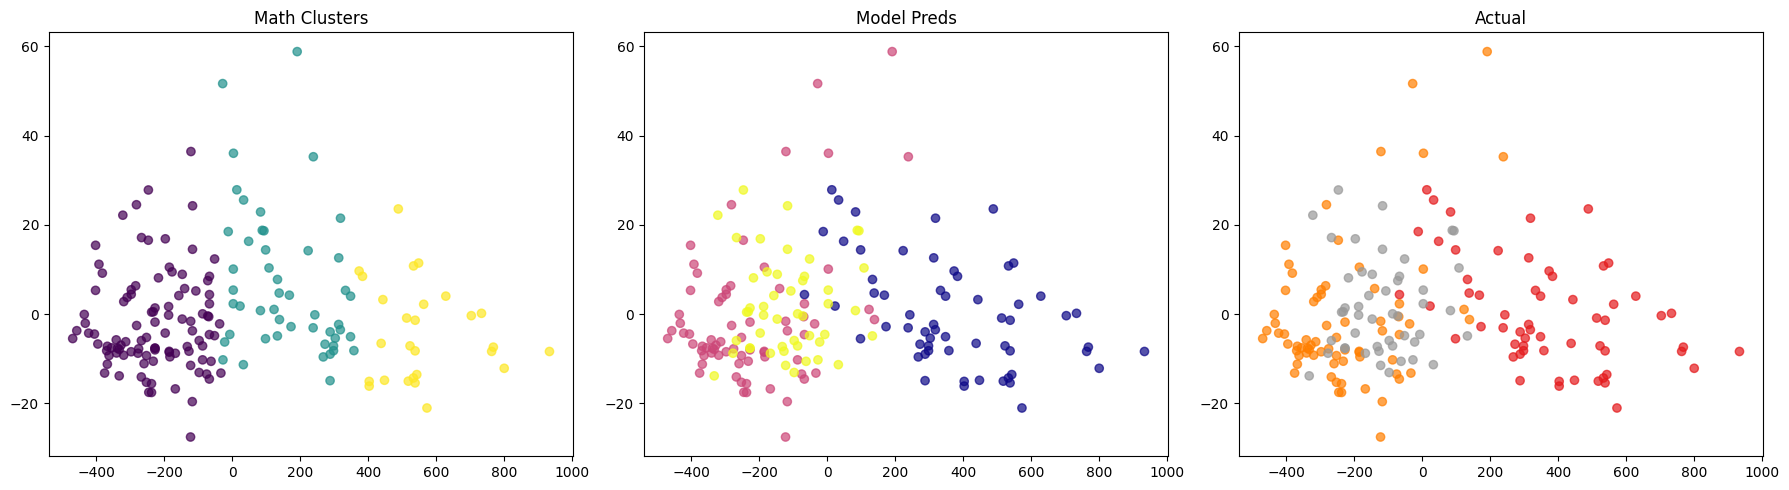

In [20]:
# plotting all three views next to each other
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-means clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans,
                cmap="viridis", alpha=0.7)
axes[0].set_title("Math Clusters")

# supervised model (I used RF here)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=pred_rf,
                cmap="plasma", alpha=0.7)
axes[1].set_title("Model Preds")

# ground truth labels
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                cmap="Set1", alpha=0.7)
axes[2].set_title("Actual")

plt.tight_layout()
plt.show()



### Q4.C.3 Analysis & Defence
*Analysis provided in Word document.*